In [32]:
%matplotlib inline

In [2]:
import sys
print("Python:", sys.version)

import numpy as np
import gym
print("Numpy:", np.__version__)
print("Gym:", gym.__version__)

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Numpy: 1.26.1
Gym: 0.26.2


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
from ChefsHatGym.gameRooms.chefs_hat_room_local import ChefsHatRoomLocal
from ChefsHatGym.env import ChefsHatEnv
from ChefsHatGym.agents.agent_random import AgentRandon
from ChefsHatGym.agents.base_classes.chefs_hat_player import ChefsHatPlayer

print("✅ Chef's Hat imports OK")

✅ Chef's Hat imports OK


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\envs\registration.py:498: UserWarning: WARN: Overriding environment chefshat-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [4]:
import logging, contextlib, io
logging.disable(logging.CRITICAL)

def run_silent(fn, *args, **kwargs):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        return fn(*args, **kwargs)

In [5]:
def play_game(players, stop_criteria=1, room_name="room"):
    room = ChefsHatRoomLocal(
        room_name=room_name,
        game_type=ChefsHatEnv.GAMETYPE["MATCHES"],
        stop_criteria=stop_criteria,
    )
    for p in players:
        room.add_player(p)

    info = run_silent(room.start_new_game)
    return info

In [6]:
def get_agent_perf(info, agent_index: int = 0) -> float:
    scores = info.get("Game_Performance_Score", None)
    if not isinstance(scores, (list, tuple)) or len(scores) <= agent_index:
        return 0.0
    return float(scores[agent_index])

In [7]:
import numpy as np

class GreedyOpponent(ChefsHatPlayer):
    def __init__(self, name="G3", agent_suffix="G"):
        super().__init__(name, agent_suffix)
        self.name = name
        self.agent_suffix = agent_suffix
        self.player_key = f"{name}_{agent_suffix}"

    def get_action(self, observation):
        mask = np.array(observation[28:])
        valid = np.where(mask > 0.5)[0]
        idx = int(valid.max()) if len(valid) else 0
        a = np.zeros(200, dtype=np.int32); a[idx] = 1
        return a.tolist()

    def get_exhanged_cards(self, cards, amount):
        return sorted(cards, reverse=True)[:amount]

    def do_special_action(self, info, specialAction): return False
    def update_start_match(self, cards, players, starting_player): pass
    def update_my_action(self, info): pass
    def update_action_others(self, info): pass
    def update_end_match(self, info): pass
    def get_reward(self, info): return 0
    def update_game_over(self): pass


class ConservativeOpponent(ChefsHatPlayer):
    def __init__(self, name="C4", agent_suffix="C"):
        super().__init__(name, agent_suffix)
        self.name = name
        self.agent_suffix = agent_suffix
        self.player_key = f"{name}_{agent_suffix}"

    def get_action(self, observation):
        mask = np.array(observation[28:])
        valid = np.where(mask > 0.5)[0]
        idx = int(valid.min()) if len(valid) else 0
        a = np.zeros(200, dtype=np.int32); a[idx] = 1
        return a.tolist()

    def get_exhanged_cards(self, cards, amount):
        return sorted(cards)[:amount]

    def do_special_action(self, info, specialAction): return False
    def update_start_match(self, cards, players, starting_player): pass
    def update_my_action(self, info): pass
    def update_action_others(self, info): pass
    def update_end_match(self, info): pass
    def get_reward(self, info): return 0
    def update_game_over(self): pass


def opponents_random():
    return [AgentRandon("R2"), AgentRandon("R3"), AgentRandon("R4")]

def opponents_mixed():
    return [AgentRandon("R2"), GreedyOpponent("G3","G"), ConservativeOpponent("C4","C")]

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class PolicyNet(nn.Module):
    def __init__(self, obs_dim=228, act_dim=200):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, act_dim),
        )
    def forward(self, x): return self.net(x)

class RLPlayerREINFORCE(ChefsHatPlayer):
    def __init__(self, name="RL", agent_suffix="RL", lr=1e-4, device="cpu"):
        super().__init__(name, agent_suffix)
        self.name = name
        self.agent_suffix = agent_suffix
        self.player_key = f"{name}_{agent_suffix}"

        self.device = device
        self.policy = PolicyNet().to(device)
        self.optim = optim.Adam(self.policy.parameters(), lr=lr)

        self.saved_logprobs = []
        self.training_enabled = True
        self.episode_done = False

    def set_training(self, enabled: bool):
        self.training_enabled = enabled

    def update_start_match(self, cards, players, starting_player):
        self.saved_logprobs = []
        self.episode_done = False

    def get_action(self, observation):
        obs = torch.tensor(observation, dtype=torch.float32, device=self.device)
        mask = obs[28:]
        logits = self.policy(obs)

        very_neg = torch.tensor(-1e9, device=self.device)
        masked_logits = torch.where(mask > 0.5, logits, very_neg)

        probs = torch.softmax(masked_logits, dim=-1)
        dist = torch.distributions.Categorical(probs=probs)
        action_idx = dist.sample()

        if self.training_enabled:
            self.saved_logprobs.append(dist.log_prob(action_idx))

        a = np.zeros(200, dtype=np.int32)
        a[action_idx.item()] = 1
        return a.tolist()

    def get_exhanged_cards(self, cards, amount):
        return sorted(cards, reverse=True)[:amount]

    def do_special_action(self, info, specialAction): return False
    def update_my_action(self, info): pass
    def update_action_others(self, info): pass
    def update_game_over(self): pass
    def get_reward(self, info): return 0

    def update_end_match(self, info):
        if not self.training_enabled or self.episode_done:
            return
        self.episode_done = True

        R = get_agent_perf(info, agent_index=0)
        if len(self.saved_logprobs) == 0:
            return

        loss = -torch.stack(self.saved_logprobs).sum() * R
        self.optim.zero_grad()
        loss.backward()
        self.optim.step()
        self.saved_logprobs = []

In [9]:
import numpy as np

def evaluate(agent, opponent_factory, games=5, stop_criteria=1):
    agent.set_training(False)
    scores = []
    for g in range(games):
        info = play_game([agent] + opponent_factory(), stop_criteria=stop_criteria, room_name=f"eval_{g}")
        scores.append(get_agent_perf(info, agent_index=0))  # agent is first
    agent.set_training(True)
    return float(np.mean(scores)), float(np.std(scores))

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = RLPlayerREINFORCE(name="RL", agent_suffix="RL", lr=1e-4, device=device)

m1, s1 = evaluate(agent, opponents_random, games=30, stop_criteria=3)
m2, s2 = evaluate(agent, opponents_mixed, games=30, stop_criteria=3)

print(f"Baseline vs Random: mean={m1:.3f}, std={s1:.3f}")
print(f"Baseline vs Mixed : mean={m2:.3f}, std={s2:.3f}")

Agent RL_RL log folder:  C:\Users\syedw\RL_RL
Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


...

Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent G3_G log folder:  C:\Users\syedw\G3_G
Agent C4_C log folder:  C:\Users\syedw\C4_C


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent G3_G log folder:  C:\Users\syedw\G3_G
Agent C4_C log folder:  C:\Users\syedw\C4_C


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Baseline vs Random: mean=0.688, std=0.277
Baseline vs Mixed : mean=0.910, std=0.215


In [44]:
def train(agent, opponent_factory, num_games=30, stop_criteria=3):
    curve = []
    for g in range(num_games):
        info = play_game([agent] + opponent_factory(), stop_criteria=stop_criteria, room_name=f"train_{g}")
        curve.append(get_agent_perf(info, agent_index=0))  # agent is first
        if (g+1) % 5 == 0:
            print(f"Game {g+1}/{num_games} | last score={curve[-1]:.3f}")
    return curve

Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


...

Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Game 30/30 | last score=0.760


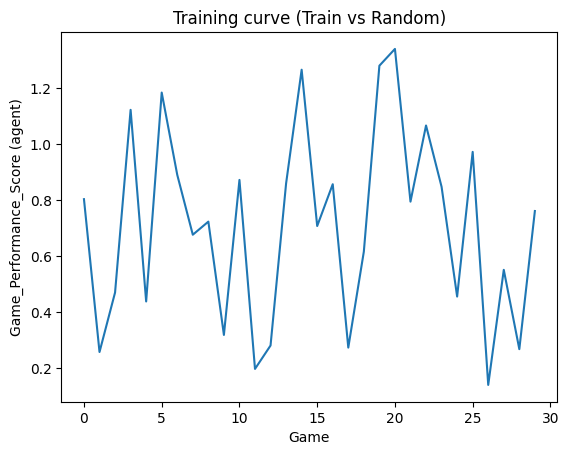

In [46]:
curve_random = train(agent, opponents_random, num_games=30, stop_criteria=3)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(curve_random)
plt.title("Training curve (Train vs Random)")
plt.xlabel("Game")
plt.ylabel("Game_Performance_Score (agent)")
plt.show()

In [48]:
m1_t, s1_t = evaluate(agent, opponents_random, games=30, stop_criteria=3)
m2_t, s2_t = evaluate(agent, opponents_mixed, games=30, stop_criteria=3)

print(f"After training vs Random: mean={m1_t:.3f}, std={s1_t:.3f}")
print(f"After training vs Mixed : mean={m2_t:.3f}, std={s2_t:.3f}")

Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


...

Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent G3_G log folder:  C:\Users\syedw\G3_G
Agent C4_C log folder:  C:\Users\syedw\C4_C


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent G3_G log folder:  C:\Users\syedw\G3_G
Agent C4_C log folder:  C:\Users\syedw\C4_C


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


After training vs Random: mean=0.718, std=0.298
After training vs Mixed : mean=0.906, std=0.242


Saved: task2_outputs/results.csv
Saved: task2_outputs/training_curve_random.png


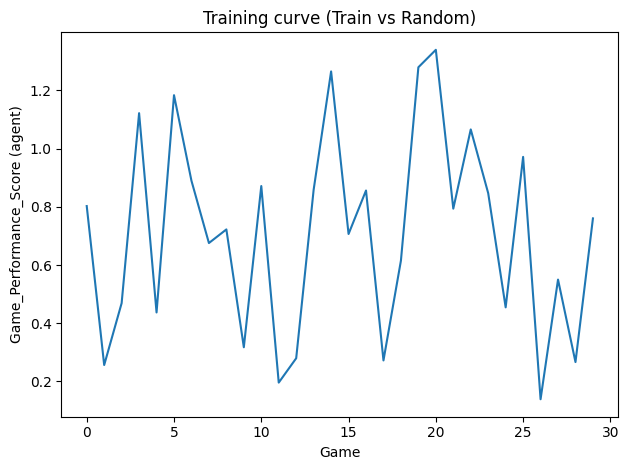

In [50]:
import os, pandas as pd
os.makedirs("task2_outputs", exist_ok=True)

results = pd.DataFrame([
    {"stage":"Baseline", "opponents":"Random", "mean":m1, "std":s1},
    {"stage":"Baseline", "opponents":"Mixed",  "mean":m2, "std":s2},
    {"stage":"Trained(vs Random)", "opponents":"Random", "mean":m1_t, "std":s1_t},
    {"stage":"Trained(vs Random)", "opponents":"Mixed",  "mean":m2_t, "std":s2_t},
])

results.to_csv("task2_outputs/results.csv", index=False)
print("Saved: task2_outputs/results.csv")

plt.figure()
plt.plot(curve_random)
plt.title("Training curve (Train vs Random)")
plt.xlabel("Game")
plt.ylabel("Game_Performance_Score (agent)")
plt.tight_layout()
plt.savefig("task2_outputs/training_curve_random.png", dpi=200)
print("Saved: task2_outputs/training_curve_random.png")
plt.show()

In [52]:
info = play_game([agent] + opponents_random(), stop_criteria=1, room_name="debug_eval")

print("Player_Names:", info.get("Player_Names"))
print("Game_Performance_Score:", info.get("Game_Performance_Score"))

Agent RANDOM_R2 log folder:  C:\Users\syedw\RANDOM_R2
Agent RANDOM_R3 log folder:  C:\Users\syedw\RANDOM_R3
Agent RANDOM_R4 log folder:  C:\Users\syedw\RANDOM_R4


C:\Users\syedw\anaconda3\envs\chefhat\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Player_Names: ['RL', 'RANDOM_R2', 'RANDOM_R3', 'RANDOM_R4']
Game_Performance_Score: [0.9523809523809523, 0.47619047619047616, 1.4285714285714286, 0.0]
